<a href="https://colab.research.google.com/github/tamara-kostova/MSc_Thesis_Neuroimaging/blob/master/19_Uncertainty_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uncertainty Evaluation

## Setup

In [ ]:
!pip install open_clip_torch ftfy regex tqdm pillow -q
!pip install transformers datasets -q
!pip install matplotlib seaborn scikit-learn -q
!pip install "numpy<2" -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/bin/python3.10 -m pip install --upgrade pip


## GPU Check & Memory Info

In [ ]:
import torch
import gc

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"Total GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Reserved Memory: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
    print(f"Allocated Memory: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")

# Clear any existing GPU cache
torch.cuda.empty_cache()
gc.collect()
print("\n✅ GPU cache cleared")

CUDA available: True
GPU: NVIDIA GeForce GTX 1660 Ti
Total GPU Memory: 6.23 GB
Reserved Memory: 0.00 GB
Allocated Memory: 0.00 GB

✅ GPU cache cleared


## Import Libraries

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import open_clip
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve
from typing import Dict, List, Tuple, Optional
import warnings
import gc
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Memory Management Utilities

In [ ]:
def clear_memory():
    """Aggressively clear GPU memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def print_memory_stats(prefix=""):
    """Print current GPU memory usage"""
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated(0) / 1e9
        reserved = torch.cuda.memory_reserved(0) / 1e9
        print(f"{prefix}GPU Memory - Allocated: {allocated:.2f}GB, Reserved: {reserved:.2f}GB")

def move_to_cpu(tensor_dict):
    """Move all tensors in dict to CPU to free GPU memory"""
    return {k: v.cpu() if torch.is_tensor(v) else v for k, v in tensor_dict.items()}

## Configuration

In [ ]:
class Config:
    """Memory-optimized configuration"""

    # Paths
    BASE_DIR = "/mnt/gdrive/MSc_Thesis_Neuroimaging"
    SPLIT_DIR = f"{BASE_DIR}/data/split"
    RESULTS_DIR = f"{BASE_DIR}/results/benchmarks"
    CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"

    # MEMORY OPTIMIZED: Smaller batch size
    BATCH_SIZE = 4  # Reduced from 32

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Random seed
    SEED = 42

    # Calibration split
    VAL_SPLIT_RATIO = 0.2

    # MEMORY OPTIMIZED: Use smaller CLIP model
    CLIP_MODEL = "ViT-B-32"  # Smaller than ViT-B-16
    CLIP_PRETRAINED = "openai"

# Set random seeds
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)
    # MEMORY OPTIMIZED: Set memory allocation config
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

print(f"✅ Configuration set - Using {Config.CLIP_MODEL} model")
print(f"   Batch size: {Config.BATCH_SIZE}")
print(f"   Device: {Config.DEVICE}")

✅ Configuration set - Using ViT-B-32 model
   Batch size: 4
   Device: cuda


## Dataset

In [ ]:
class MedicalImageDataset(Dataset):
    """PyTorch Dataset for medical images"""

    def __init__(self, split_dir, split_type="test", transform=None):
        self.split_dir = split_dir
        self.split_type = split_type
        self.transform = transform

        self.samples = []
        self.class_to_idx = {}

        split_path = os.path.join(split_dir, split_type)
        if not os.path.exists(split_path):
            raise FileNotFoundError(f"Split directory not found: {split_path}")

        class_folders = sorted([d for d in os.listdir(split_path)
                              if os.path.isdir(os.path.join(split_path, d))])

        self.class_to_idx = {cls: idx for idx, cls in enumerate(class_folders)}

        for class_name in class_folders:
            class_dir = os.path.join(split_path, class_name)
            class_idx = self.class_to_idx[class_name]

            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.npy')):
                    img_path = os.path.join(class_dir, img_name)
                    self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        if img_path.endswith('.npy'):
            img_array = np.load(img_path)
            if img_array.ndim == 2:
                img_array = np.stack([img_array]*3, axis=-1)
            img = Image.fromarray(img_array.astype('uint8'))
        else:
            img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label


def get_test_loader(split_dir, batch_size=4, num_workers=0, transform=None):
    """Create test data loader - MEMORY OPTIMIZED"""
    test_dataset = MedicalImageDataset(split_dir, split_type="test", transform=transform)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False
    )
    return test_loader, test_dataset

## Temperature Scaling

In [ ]:
class TemperatureScaling:
    """Temperature scaling"""

    def __init__(self):
        self.temperature = 1.0

    def find_optimal_temperature(
        self,
        logits: torch.Tensor,
        labels: torch.Tensor,
        metric: str = 'nll',
        temps: np.ndarray = None,
        verbose: bool = True
    ) -> Tuple[float, float]:
        logits = logits.cpu()
        labels = labels.cpu()

        if temps is None:
            temps = np.linspace(0.5, 3.0, 50)

        best_temp = 1.0
        best_score = float('inf')

        for temp in temps:
            scaled_probs = F.softmax(logits / temp, dim=1)

            if metric == 'nll':
                nll = F.nll_loss(
                    torch.log(scaled_probs + 1e-12),
                    labels
                ).item()
                score = nll
            elif metric == 'ece':
                score = self._compute_ece(scaled_probs, labels)
            else:
                raise ValueError(f"Unknown metric: {metric}")

            if score < best_score:
                best_score = score
                best_temp = temp

        self.temperature = best_temp

        if verbose:
            print(f"🌡️  Optimal temperature: {best_temp:.3f}")
            print(f"   {metric.upper()} score: {best_score:.4f}")

        return best_temp, best_score

    def apply(self, logits: torch.Tensor) -> torch.Tensor:
        """Apply temperature scaling"""
        return F.softmax(logits / self.temperature, dim=1)

    @staticmethod
    def _compute_ece(probs: torch.Tensor, labels: torch.Tensor, n_bins: int = 15) -> float:
        """Compute ECE on CPU"""
        confidences, predictions = torch.max(probs, dim=1)
        accuracies = predictions.eq(labels)

        ece = 0.0
        bin_boundaries = torch.linspace(0, 1, n_bins + 1)

        for i in range(n_bins):
            bin_lower = bin_boundaries[i]
            bin_upper = bin_boundaries[i + 1]

            in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
            prop_in_bin = in_bin.float().mean()

            if prop_in_bin > 0:
                accuracy_in_bin = accuracies[in_bin].float().mean()
                avg_confidence_in_bin = confidences[in_bin].mean()
                ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

        return ece.item()

## Enhanced Uncertainty Metrics

In [ ]:
def compute_ece(probs: torch.Tensor, labels: torch.Tensor, n_bins: int = 15) -> float:
    """Compute ECE - CPU version"""
    probs = probs.cpu()
    labels = labels.cpu()

    confidences, predictions = torch.max(probs, dim=1)
    accuracies = predictions.eq(labels)

    ece = 0.0
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.float().mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece.item()


def compute_uncertainty_auroc(
    probs: torch.Tensor,
    labels: torch.Tensor,
    uncertainty: torch.Tensor
) -> float:
    """Compute AUROC for error detection"""
    predictions = torch.argmax(probs, dim=1)
    errors = (predictions != labels).cpu().numpy()
    uncertainty_np = uncertainty.cpu().numpy()

    if len(np.unique(errors)) < 2:
        return 0.5

    return roc_auc_score(errors, uncertainty_np)


def compute_selective_prediction_curve(
    probs: torch.Tensor,
    labels: torch.Tensor,
    uncertainty: torch.Tensor,
    n_points: int = 50
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute selective prediction curve"""
    predictions = torch.argmax(probs, dim=1)
    confidences, _ = torch.max(probs, dim=1)

    sorted_indices = torch.argsort(uncertainty)

    coverages = []
    accuracies = []
    avg_confidences = []

    n_samples = len(predictions)

    for i in range(1, n_samples + 1, max(1, n_samples // n_points)):
        selected_indices = sorted_indices[:i]

        coverage = i / n_samples
        accuracy = (predictions[selected_indices] == labels[selected_indices]).float().mean().item()
        avg_conf = confidences[selected_indices].mean().item()

        coverages.append(coverage)
        accuracies.append(accuracy)
        avg_confidences.append(avg_conf)

    return np.array(coverages), np.array(accuracies), np.array(avg_confidences)


def compute_all_metrics(
    probs: torch.Tensor,
    labels: torch.Tensor,
    uncertainty: torch.Tensor,
    method_name: str = ""
) -> Dict[str, float]:
    """Compute all metrics"""
    predictions = torch.argmax(probs, dim=1)
    accuracy = (predictions == labels).float().mean().item()

    metrics = {
        'method': method_name,
        'accuracy': accuracy,
        'ece': compute_ece(probs, labels),
        'error_auroc': compute_uncertainty_auroc(probs, labels, uncertainty),
    }

    coverages, accs, confs = compute_selective_prediction_curve(
        probs, labels, uncertainty
    )

    for cov in [0.5, 0.7, 0.8, 0.9]:
        idx = int(len(accs) * cov) - 1
        if idx >= 0:
            metrics[f'acc@{int(cov*100)}%'] = accs[idx]

    return metrics

## Prompt Builder

In [ ]:
def build_prompts(dataset_name: str, class_names: List[str]) -> List[str]:
    """Build task-specific prompts"""
    prompt_templates = {
        'MRI_tumor_binary_norm': [
            "a brain MRI scan showing a brain tumor",
            "a brain MRI scan showing a healthy brain without tumor"
        ],
        'MRI_tumor_multiclass_norm': [
            "a brain MRI scan showing a glioma tumor",
            "a brain MRI scan showing a meningioma tumor",
            "a brain MRI scan showing a healthy brain without tumor",
            "a brain MRI scan showing a pituitary tumor"
        ],
        'CT_stroke_binary_norm': [
            "a brain CT scan showing ischemic stroke",
            "a brain CT scan showing a normal brain without stroke"
        ],
        'MRI_ms_norm': [
            "a brain MRI scan showing active multiple sclerosis lesions",
            "a brain MRI scan showing inactive multiple sclerosis lesions"
        ]
    }

    if dataset_name in prompt_templates:
        return prompt_templates[dataset_name]
    else:
        return [f"a medical image showing {cls}" for cls in class_names]

## Uncertainty Estimator

In [ ]:
class UncertaintyEstimator:
    """Uncertainty Estimator"""

    def __init__(
        self,
        model_name: str = None,
        pretrained: str = None,
        device: Optional[torch.device] = None
    ):
        self.device = device or Config.DEVICE

        # Use config defaults if not specified
        model_name = model_name or Config.CLIP_MODEL
        pretrained = pretrained or Config.CLIP_PRETRAINED

        print(f"Loading {model_name} ({pretrained})...")

        # Clear memory before loading
        clear_memory()

        # Load CLIP model
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name, pretrained=pretrained
        )
        self.model = self.model.to(self.device)
        self.model.eval()

        # Enable memory efficient mode
        if hasattr(self.model, 'set_grad_checkpointing'):
            self.model.set_grad_checkpointing()

        self.tokenizer = open_clip.get_tokenizer(model_name)

        self.class_names = None
        self.text_features = None

        print_memory_stats("After model load: ")

    def set_classes(self, class_names: List[str], prompts: Optional[List[str]] = None):
        """Set class names and encode text features"""
        self.class_names = class_names

        if prompts is None:
            prompts = [f"a photo of {cls}" for cls in class_names]

        text_tokens = self.tokenizer(prompts).to(self.device)

        with torch.no_grad():
            self.text_features = self.model.encode_text(text_tokens)
            self.text_features = F.normalize(self.text_features, dim=-1)

        # Move to CPU to save GPU memory
        self.text_features = self.text_features.cpu()

        clear_memory()

    @torch.no_grad()
    def predict(
        self,
        images: torch.Tensor,
        return_logits: bool = True
    ) -> Dict[str, torch.Tensor]:
        """Predict with memory optimization"""
        images = images.to(self.device)

        # Encode images
        image_features = self.model.encode_image(images)
        image_features = F.normalize(image_features, dim=-1)

        # Move text features to GPU temporarily
        text_features = self.text_features.to(self.device)

        # Compute logits
        logits = 100.0 * image_features @ text_features.T

        # Move text features back to CPU
        text_features = text_features.cpu()

        # Compute probabilities
        probs = F.softmax(logits, dim=-1)

        # Compute uncertainty
        uncertainty = -(probs * torch.log(probs + 1e-12)).sum(dim=1)

        # Move to CPU immediately to free GPU memory
        result = {
            'probs': probs.cpu(),
            'uncertainty': uncertainty.cpu()
        }

        if return_logits:
            result['logits'] = logits.cpu()

        # Clear GPU cache
        clear_memory()

        return result

    @torch.no_grad()
    def predict_mc_dropout(
        self,
        images: torch.Tensor,
        n_samples: int = 5,
        dropout_rate: float = 0.1,
        return_logits: bool = True
    ) -> Dict[str, torch.Tensor]:
        """MC Dropout - MEMORY OPTIMIZED"""
        images = images.to(self.device)
        all_probs = []
        all_logits = []

        self.model.train()

        for i in range(n_samples):
            # Encode with dropout
            image_features = self.model.encode_image(images)
            image_features = F.normalize(image_features, dim=-1)
            image_features = F.dropout(image_features, p=dropout_rate, training=True)

            text_features = self.text_features.to(self.device)
            logits = 100.0 * image_features @ text_features.T
            text_features = text_features.cpu()

            probs = F.softmax(logits, dim=-1)

            all_probs.append(probs.cpu())
            if return_logits:
                all_logits.append(logits.cpu())

            # Clear after each iteration
            if i % 2 == 0:  # Clear every 2 iterations
                clear_memory()

        self.model.eval()
        clear_memory()

        # Compute statistics on CPU
        all_probs = torch.stack(all_probs)
        mean_probs = all_probs.mean(dim=0)
        var_probs = all_probs.var(dim=0).mean(dim=1)

        entropy = -(mean_probs * torch.log(mean_probs + 1e-12)).sum(dim=1)
        uncertainty = entropy + var_probs

        result = {
            'probs': mean_probs,
            'uncertainty': uncertainty
        }

        if return_logits:
            mean_logits = torch.stack(all_logits).mean(dim=0)
            result['logits'] = mean_logits

        return result

    @torch.no_grad()
    def predict_tta(
        self,
        images: torch.Tensor,
        n_augmentations: int = 3,
        return_logits: bool = True
    ) -> Dict[str, torch.Tensor]:
        """TTA - MEMORY OPTIMIZED"""
        images = images.to(self.device)
        all_probs = []
        all_logits = []

        # Original
        result = self.predict(images, return_logits=return_logits)
        all_probs.append(result['probs'])
        if return_logits:
            all_logits.append(result['logits'])

        # Augmented
        for i in range(n_augmentations - 1):
            aug_images = self._random_augment(images)
            result = self.predict(aug_images, return_logits=return_logits)
            all_probs.append(result['probs'])
            if return_logits:
                all_logits.append(result['logits'])

            if i % 2 == 0:
                clear_memory()

        clear_memory()

        # Compute statistics
        all_probs = torch.stack(all_probs)
        mean_probs = all_probs.mean(dim=0)
        var_probs = all_probs.var(dim=0).mean(dim=1)

        entropy = -(mean_probs * torch.log(mean_probs + 1e-12)).sum(dim=1)
        uncertainty = entropy + var_probs

        result = {
            'probs': mean_probs,
            'uncertainty': uncertainty
        }

        if return_logits:
            mean_logits = torch.stack(all_logits).mean(dim=0)
            result['logits'] = mean_logits

        return result

    def _random_augment(self, images: torch.Tensor) -> torch.Tensor:
        """Apply random augmentation"""
        angle = np.random.uniform(-10, 10)
        images = transforms.functional.rotate(images, angle)
        images = transforms.functional.adjust_brightness(images, np.random.uniform(0.9, 1.1))
        images = transforms.functional.adjust_contrast(images, np.random.uniform(0.9, 1.1))
        return images

## 🆕 Memory-Optimized Evaluation Pipeline

In [ ]:
def run_comprehensive_evaluation(
    estimator: UncertaintyEstimator,
    test_loader: DataLoader,
    val_loader: Optional[DataLoader] = None,
    use_temp_scaling: bool = True,
    dataset_name: str = ""
) -> Tuple[Dict, pd.DataFrame, torch.Tensor]:
    """
    evaluation pipeline
    """
    print(f"\n{'='*80}")
    print(f"UNCERTAINTY EVALUATION: {dataset_name}")
    print(f"{'='*80}\n")

    device = estimator.device
    results = {}

    # Temperature Calibration
    temp_scaler = None

    if use_temp_scaling and val_loader is not None:
        print("\n🌡️  STEP 1: Temperature Calibration")
        print("-" * 80)

        val_logits = []
        val_labels = []

        print("Collecting validation logits...")
        for images, labels in tqdm(val_loader, desc="Validation"):
            result = estimator.predict(images, return_logits=True)
            val_logits.append(result['logits'])
            val_labels.append(labels)

            # Clear every few batches
            if len(val_logits) % 5 == 0:
                clear_memory()

        val_logits = torch.cat(val_logits)
        val_labels = torch.cat(val_labels)

        # Temperature scaling on CPU
        temp_scaler = TemperatureScaling()
        optimal_temp, nll_score = temp_scaler.find_optimal_temperature(
            val_logits, val_labels, metric='nll', verbose=True
        )

        print(f"✅ Temperature calibration complete!\n")
        clear_memory()

    # Run All Methods
    methods = {
        'baseline': lambda img: estimator.predict(img, return_logits=True),
        'mc_dropout': lambda img: estimator.predict_mc_dropout(img, n_samples=5, return_logits=True),
        'tta': lambda img: estimator.predict_tta(img, n_augmentations=3, return_logits=True)
    }

    all_labels = []

    for method_name, method_func in methods.items():
        print(f"\n📊 Running {method_name.upper()}")
        print("-" * 80)

        all_probs = []
        all_logits = []
        all_uncertainty = []
        batch_labels = []

        for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc=f"{method_name}")):
            result = method_func(images)

            all_probs.append(result['probs'])  # Already on CPU
            all_logits.append(result['logits'])
            all_uncertainty.append(result['uncertainty'])
            batch_labels.append(labels)

            # Clear GPU cache every 10 batches
            if batch_idx % 10 == 0:
                clear_memory()

        probs = torch.cat(all_probs)
        logits = torch.cat(all_logits)
        uncertainty = torch.cat(all_uncertainty)
        labels_tensor = torch.cat(batch_labels)

        if method_name == 'baseline':
            all_labels = labels_tensor

        results[method_name] = {
            'probs': probs,
            'logits': logits,
            'uncertainty': uncertainty
        }

        # Temperature scaling
        if temp_scaler is not None:
            calibrated_probs = temp_scaler.apply(logits)
            calibrated_uncertainty = -(calibrated_probs * torch.log(calibrated_probs + 1e-12)).sum(dim=1)

            results[f'{method_name}_temp'] = {
                'probs': calibrated_probs,
                'logits': logits,
                'uncertainty': calibrated_uncertainty
            }

        clear_memory()
        print_memory_stats(f"{method_name} complete: ")

    # Compute Metrics
    print(f"\n\n📈 Computing Metrics")
    print("-" * 80)

    all_metrics = []

    for method_name, method_results in results.items():
        metrics = compute_all_metrics(
            method_results['probs'],
            all_labels,
            method_results['uncertainty'],
            method_name=method_name
        )
        metrics['dataset'] = dataset_name
        all_metrics.append(metrics)

    metrics_df = pd.DataFrame(all_metrics)

    # Print Results
    print("\n\n" + "="*80)
    print("📊 RESULTS SUMMARY")
    print("="*80)

    display_df = metrics_df[['method', 'accuracy', 'ece', 'error_auroc']].copy()
    display_df['accuracy'] = display_df['accuracy'].apply(lambda x: f"{x:.4f}")
    display_df['ece'] = display_df['ece'].apply(lambda x: f"{x:.4f}")
    display_df['error_auroc'] = display_df['error_auroc'].apply(lambda x: f"{x:.4f}")

    print("\n" + display_df.to_string(index=False))
    print("\n" + "="*80)

    best_ece = metrics_df.loc[metrics_df['ece'].idxmin()]
    best_auroc = metrics_df.loc[metrics_df['error_auroc'].idxmax()]

    print(f"\n🏆 Best ECE: {best_ece['method']} = {best_ece['ece']:.4f}")
    print(f"🏆 Best AUROC: {best_auroc['method']} = {best_auroc['error_auroc']:.4f}")
    print("\n" + "="*80)

    clear_memory()

    return results, metrics_df, all_labels

## Visualization

In [ ]:
def create_comprehensive_plots(
    results: Dict,
    labels: torch.Tensor,
    dataset_name: str = "",
    save_dir: str = './enhanced_results'
):
    """Create plots - memory optimized"""
    os.makedirs(save_dir, exist_ok=True)

    fig = plt.figure(figsize=(18, 10))

    # 1. Calibration Curves
    ax1 = plt.subplot(2, 3, 1)

    for method_name, method_results in results.items():
        probs = method_results['probs']
        confidences, predictions = torch.max(probs, dim=1)
        accuracies = predictions.eq(labels)

        n_bins = 15
        bin_boundaries = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2

        bin_accs = []
        bin_confs = []

        for i in range(n_bins):
            in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
            if in_bin.sum() > 0:
                bin_accs.append(accuracies[in_bin].float().mean().item())
                bin_confs.append(confidences[in_bin].mean().item())
            else:
                bin_accs.append(0)
                bin_confs.append(bin_centers[i])

        label = method_name.replace('_', ' ').title()
        ax1.plot(bin_confs, bin_accs, marker='o', label=label, linewidth=2)

    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect')
    ax1.set_xlabel('Confidence')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Calibration Curves', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # 2. Error Detection ROC
    ax2 = plt.subplot(2, 3, 2)

    for method_name, method_results in results.items():
        probs = method_results['probs']
        uncertainty = method_results['uncertainty']

        predictions = torch.argmax(probs, dim=1)
        errors = (predictions != labels).cpu().numpy()
        uncertainty_np = uncertainty.cpu().numpy()

        if len(np.unique(errors)) >= 2:
            fpr, tpr, _ = roc_curve(errors, uncertainty_np)
            auroc = roc_auc_score(errors, uncertainty_np)
            label = f"{method_name.replace('_', ' ').title()} ({auroc:.3f})"
            ax2.plot(fpr, tpr, label=label, linewidth=2)

    ax2.plot([0, 1], [0, 1], 'k--', label='Random')
    ax2.set_xlabel('FPR')
    ax2.set_ylabel('TPR')
    ax2.set_title('Error Detection ROC', fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # 3. Selective Prediction
    ax3 = plt.subplot(2, 3, 3)

    for method_name, method_results in results.items():
        probs = method_results['probs']
        uncertainty = method_results['uncertainty']

        coverages, accs, _ = compute_selective_prediction_curve(
            probs, labels, uncertainty
        )

        label = method_name.replace('_', ' ').title()
        ax3.plot(coverages, accs, label=label, linewidth=2)

    ax3.set_xlabel('Coverage')
    ax3.set_ylabel('Accuracy')
    ax3.set_title('Selective Prediction', fontweight='bold')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # 4. ECE Comparison
    ax4 = plt.subplot(2, 3, 4)

    ece_values = []
    method_labels = []

    for method_name, method_results in results.items():
        ece = compute_ece(method_results['probs'], labels)
        ece_values.append(ece)
        method_labels.append(method_name.replace('_', ' ').title())

    bars = ax4.barh(method_labels, ece_values)

    for i, (bar, val) in enumerate(zip(bars, ece_values)):
        ax4.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

    ax4.set_xlabel('ECE')
    ax4.set_title('ECE Comparison', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')

    plt.suptitle(
        f'Uncertainty Analysis - {dataset_name}',
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout()

    save_path = os.path.join(save_dir, f'{dataset_name}_analysis.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    print(f"\n💾 Saved: {save_path}")

    plt.show()
    plt.close()
    clear_memory()

## Main Execution Pipeline

In [ ]:
def run_enhanced_benchmark(
    dataset_name: str = "MRI_tumor_binary_norm",
    batch_size: int = 4,
    num_workers: int = 0,
    use_temp_scaling: bool = True
) -> Tuple[Dict, pd.DataFrame, torch.Tensor]:
    print(f"\n{'='*80}")
    print(f"🧠 MEMORY-OPTIMIZED BENCHMARK: {dataset_name}")
    print(f"{'='*80}\n")

    clear_memory()
    print_memory_stats("Initial: ")

    split_dir = os.path.join(Config.SPLIT_DIR, dataset_name)
    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Dataset not found: {split_dir}")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    test_loader, test_dataset = get_test_loader(
        split_dir,
        batch_size=batch_size,
        num_workers=num_workers,
        transform=transform
    )

    if use_temp_scaling:
        val_size = int(Config.VAL_SPLIT_RATIO * len(test_dataset))
        test_size = len(test_dataset) - val_size

        val_dataset, final_test_dataset = random_split(
            test_dataset,
            [val_size, test_size],
            generator=torch.Generator().manual_seed(Config.SEED)
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=False
        )

        final_test_loader = DataLoader(
            final_test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=False
        )

        print(f"📊 Dataset: {dataset_name}")
        print(f"   Val: {len(val_dataset)}, Test: {len(final_test_dataset)}")
    else:
        val_loader = None
        final_test_loader = test_loader
        print(f"📊 Dataset: {dataset_name}")
        print(f"   Test: {len(test_dataset)}")

    # Initialize estimator
    print("\n🔧 Initializing CLIP...")
    estimator = UncertaintyEstimator()

    prompts = build_prompts(dataset_name, test_dataset.class_to_idx.keys())
    estimator.set_classes(list(test_dataset.class_to_idx.keys()), prompts)

    print("✅ Ready")
    print_memory_stats("After setup: ")

    # Run evaluation
    results, metrics_df, labels = run_comprehensive_evaluation(
        estimator=estimator,
        test_loader=final_test_loader,
        val_loader=val_loader if use_temp_scaling else None,
        use_temp_scaling=use_temp_scaling,
        dataset_name=dataset_name
    )

    # Create plots
    print("\n🎨 Creating plots...")
    create_comprehensive_plots(
        results,
        labels,
        dataset_name=dataset_name,
        save_dir='./enhanced_results'
    )

    return results, metrics_df, labels

## RUN SINGLE DATASET


🧠 MEMORY-OPTIMIZED BENCHMARK: MRI_tumor_binary_norm

Initial: GPU Memory - Allocated: 0.00GB, Reserved: 0.00GB
📊 Dataset: MRI_tumor_binary_norm
   Val: 90, Test: 360

🔧 Initializing CLIP...
Loading ViT-B-32 (openai)...
After model load: GPU Memory - Allocated: 0.61GB, Reserved: 0.66GB
✅ Ready
After setup: GPU Memory - Allocated: 0.62GB, Reserved: 0.67GB

🔬 MEMORY-OPTIMIZED UNCERTAINTY EVALUATION: MRI_tumor_binary_norm


🌡️  STEP 1: Temperature Calibration
--------------------------------------------------------------------------------


Validation: 100%|██████████| 45/45 [01:36<00:00,  2.15s/it]


🌡️  Optimal temperature: 3.000
   NLL score: 0.7321
✅ Temperature calibration complete!


📊 Running BASELINE
--------------------------------------------------------------------------------


baseline: 100%|██████████| 180/180 [07:15<00:00,  2.42s/it]


baseline complete: GPU Memory - Allocated: 0.62GB, Reserved: 0.67GB

📊 Running MC_DROPOUT
--------------------------------------------------------------------------------


mc_dropout: 100%|██████████| 180/180 [08:10<00:00,  2.72s/it]


mc_dropout complete: GPU Memory - Allocated: 0.62GB, Reserved: 0.67GB

📊 Running TTA
--------------------------------------------------------------------------------


tta: 100%|██████████| 180/180 [08:06<00:00,  2.71s/it]


tta complete: GPU Memory - Allocated: 0.62GB, Reserved: 0.67GB


📈 Computing Metrics
--------------------------------------------------------------------------------


📊 RESULTS SUMMARY

         method accuracy    ece error_auroc
       baseline   0.4806 0.2952      0.2287
  baseline_temp   0.4806 0.2045      0.2287
     mc_dropout   0.4694 0.2645      0.2700
mc_dropout_temp   0.4694 0.1723      0.2728
            tta   0.3972 0.1841      0.2967
       tta_temp   0.3889 0.1418      0.4042


🏆 Best ECE: tta_temp = 0.1418
🏆 Best AUROC: tta_temp = 0.4042


🎨 Creating plots...

💾 Saved: ./enhanced_results/MRI_tumor_binary_norm_analysis.png


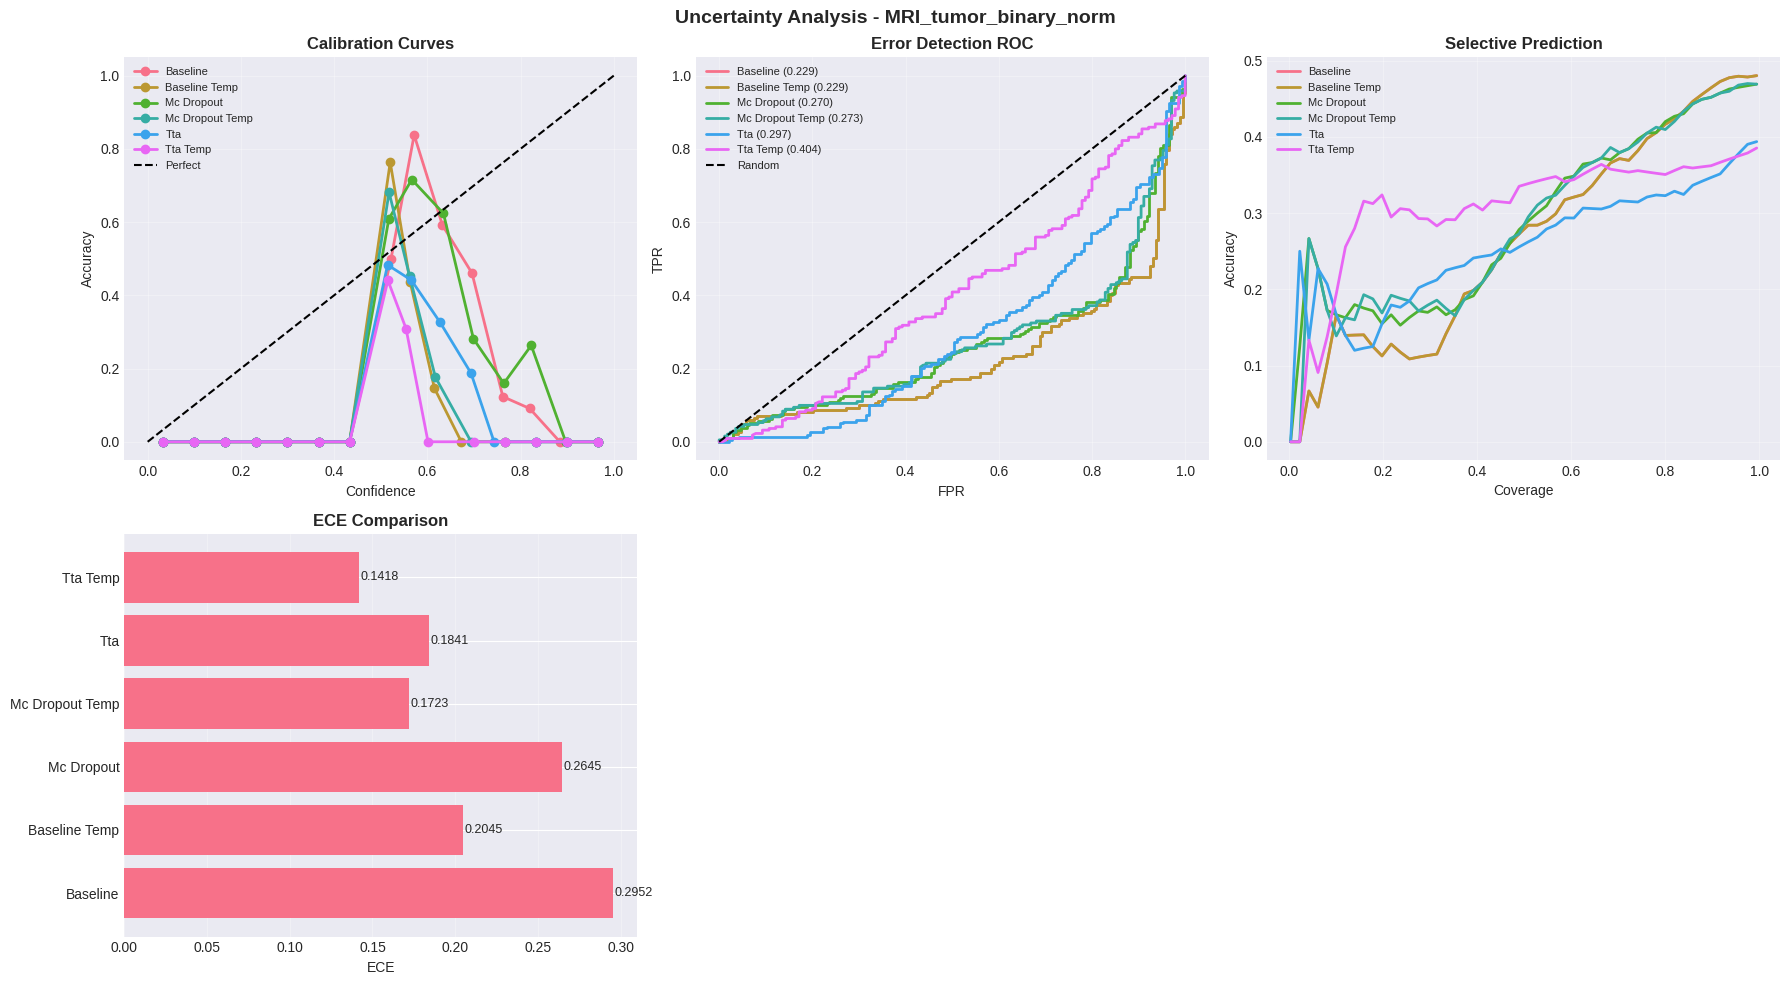


📋 DETAILED METRICS
         method  accuracy      ece  error_auroc  acc@50%  acc@70%  acc@80%  acc@90%               dataset
       baseline  0.480556 0.295207     0.228679 0.272727 0.365854 0.405694 0.455696 MRI_tumor_binary_norm
  baseline_temp  0.480556 0.204494     0.228679 0.272727 0.365854 0.405694 0.455696 MRI_tumor_binary_norm
     mc_dropout  0.469444 0.264495     0.269990 0.278409 0.369919 0.405694 0.449367 MRI_tumor_binary_norm
mc_dropout_temp  0.469444 0.172300     0.272793 0.272727 0.386179 0.412811 0.449367 MRI_tumor_binary_norm
            tta  0.397222 0.184081     0.296736 0.255682 0.308943 0.323843 0.341772 MRI_tumor_binary_norm
       tta_temp  0.388889 0.141810     0.404172 0.335227 0.357724 0.352313 0.360759 MRI_tumor_binary_norm


In [ ]:
# Clear memory before starting
clear_memory()

# Run benchmark
results, metrics_df, labels = run_enhanced_benchmark(
    dataset_name='MRI_tumor_binary_norm',
    batch_size=2,
    num_workers=0,
    use_temp_scaling=True
)

print("\n" + "="*80)
print("📋 DETAILED METRICS")
print("="*80)
print(metrics_df.to_string(index=False))

## 💾 Save Results

In [ ]:
os.makedirs('./enhanced_results', exist_ok=True)
metrics_df.to_csv('./enhanced_results/metrics.csv', index=False)
print("✅ Saved: ./enhanced_results/metrics.csv")

✅ Saved: ./enhanced_results/metrics.csv



🧠 MEMORY-OPTIMIZED BENCHMARK: MRI_ms_norm

Initial: GPU Memory - Allocated: 0.62GB, Reserved: 0.69GB
📊 Dataset: MRI_ms_norm
   Val: 117, Test: 469

🔧 Initializing CLIP...
Loading ViT-B-32 (openai)...
After model load: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB
✅ Ready
After setup: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB

🔬 MEMORY-OPTIMIZED UNCERTAINTY EVALUATION: MRI_ms_norm


🌡️  STEP 1: Temperature Calibration
--------------------------------------------------------------------------------


Validation: 100%|██████████| 59/59 [02:18<00:00,  2.35s/it]


🌡️  Optimal temperature: 3.000
   NLL score: 0.6988
✅ Temperature calibration complete!


📊 Running BASELINE
--------------------------------------------------------------------------------


baseline: 100%|██████████| 235/235 [09:04<00:00,  2.31s/it]


baseline complete: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB

📊 Running MC_DROPOUT
--------------------------------------------------------------------------------


mc_dropout: 100%|██████████| 235/235 [10:21<00:00,  2.64s/it]


mc_dropout complete: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB

📊 Running TTA
--------------------------------------------------------------------------------


tta: 100%|██████████| 235/235 [11:21<00:00,  2.90s/it]


tta complete: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB


📈 Computing Metrics
--------------------------------------------------------------------------------


📊 RESULTS SUMMARY

         method accuracy    ece error_auroc
       baseline   0.4009 0.1237      0.4702
  baseline_temp   0.4009 0.1088      0.4702
     mc_dropout   0.4030 0.1229      0.5003
mc_dropout_temp   0.4051 0.1036      0.4919
            tta   0.6759 0.1379      0.4824
       tta_temp   0.6759 0.1631      0.4864


🏆 Best ECE: mc_dropout_temp = 0.1036
🏆 Best AUROC: mc_dropout = 0.5003


🎨 Creating plots...

💾 Saved: ./enhanced_results/MRI_ms_norm_analysis.png


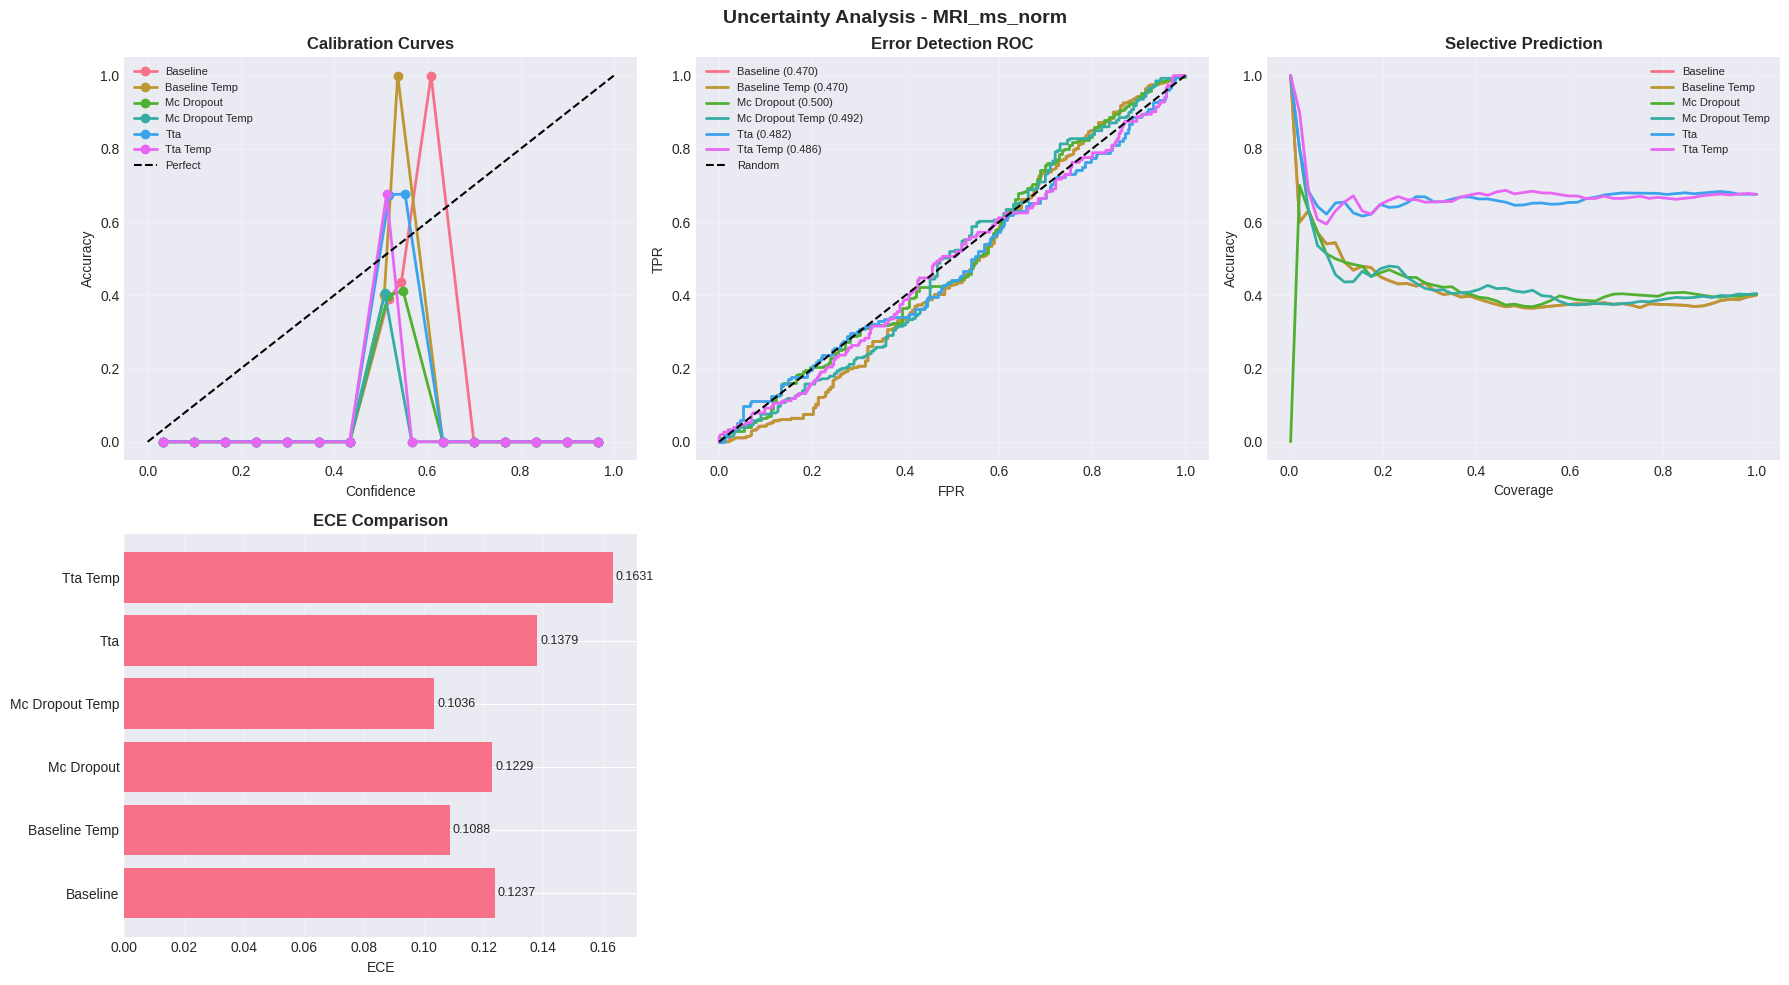


📋 DETAILED METRICS
         method  accuracy      ece  error_auroc  acc@50%  acc@70%  acc@80%  acc@90%     dataset
       baseline  0.400853 0.123724     0.470234 0.371681 0.375385 0.375676 0.371084 MRI_ms_norm
  baseline_temp  0.400853 0.108772     0.470215 0.371681 0.375385 0.375676 0.371084 MRI_ms_norm
     mc_dropout  0.402985 0.122927     0.500321 0.376106 0.403077 0.397297 0.400000 MRI_ms_norm
mc_dropout_temp  0.405117 0.103576     0.491945 0.411504 0.375385 0.386487 0.397590 MRI_ms_norm
            tta  0.675906 0.137914     0.482422 0.646018 0.676923 0.678378 0.679518 MRI_ms_norm
       tta_temp  0.675906 0.163130     0.486437 0.676991 0.664615 0.667568 0.672289 MRI_ms_norm
✅ Saved: ./enhanced_results/metrics_MRI_ms_norm.csv

🧠 MEMORY-OPTIMIZED BENCHMARK: CT_stroke_binary_norm

Initial: GPU Memory - Allocated: 0.62GB, Reserved: 0.69GB
📊 Dataset: CT_stroke_binary_norm
   Val: 199, Test: 800

🔧 Initializing CLIP...
Loading ViT-B-32 (openai)...
After model load: GPU Memory - Allo

Validation: 100%|██████████| 100/100 [03:42<00:00,  2.22s/it]


🌡️  Optimal temperature: 3.000
   NLL score: 0.7174
✅ Temperature calibration complete!


📊 Running BASELINE
--------------------------------------------------------------------------------


baseline: 100%|██████████| 400/400 [15:08<00:00,  2.27s/it]


baseline complete: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB

📊 Running MC_DROPOUT
--------------------------------------------------------------------------------


mc_dropout: 100%|██████████| 400/400 [17:34<00:00,  2.64s/it]


mc_dropout complete: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB

📊 Running TTA
--------------------------------------------------------------------------------


tta: 100%|██████████| 400/400 [18:15<00:00,  2.74s/it]


tta complete: GPU Memory - Allocated: 1.23GB, Reserved: 1.33GB


📈 Computing Metrics
--------------------------------------------------------------------------------


📊 RESULTS SUMMARY

         method accuracy    ece error_auroc
       baseline   0.5075 0.1165      0.4283
  baseline_temp   0.5075 0.0627      0.4283
     mc_dropout   0.5075 0.1151      0.4204
mc_dropout_temp   0.5075 0.0646      0.4208
            tta   0.3500 0.3009      0.4082
       tta_temp   0.3512 0.2027      0.3615


🏆 Best ECE: baseline_temp = 0.0627
🏆 Best AUROC: baseline = 0.4283


🎨 Creating plots...

💾 Saved: ./enhanced_results/CT_stroke_binary_norm_analysis.png


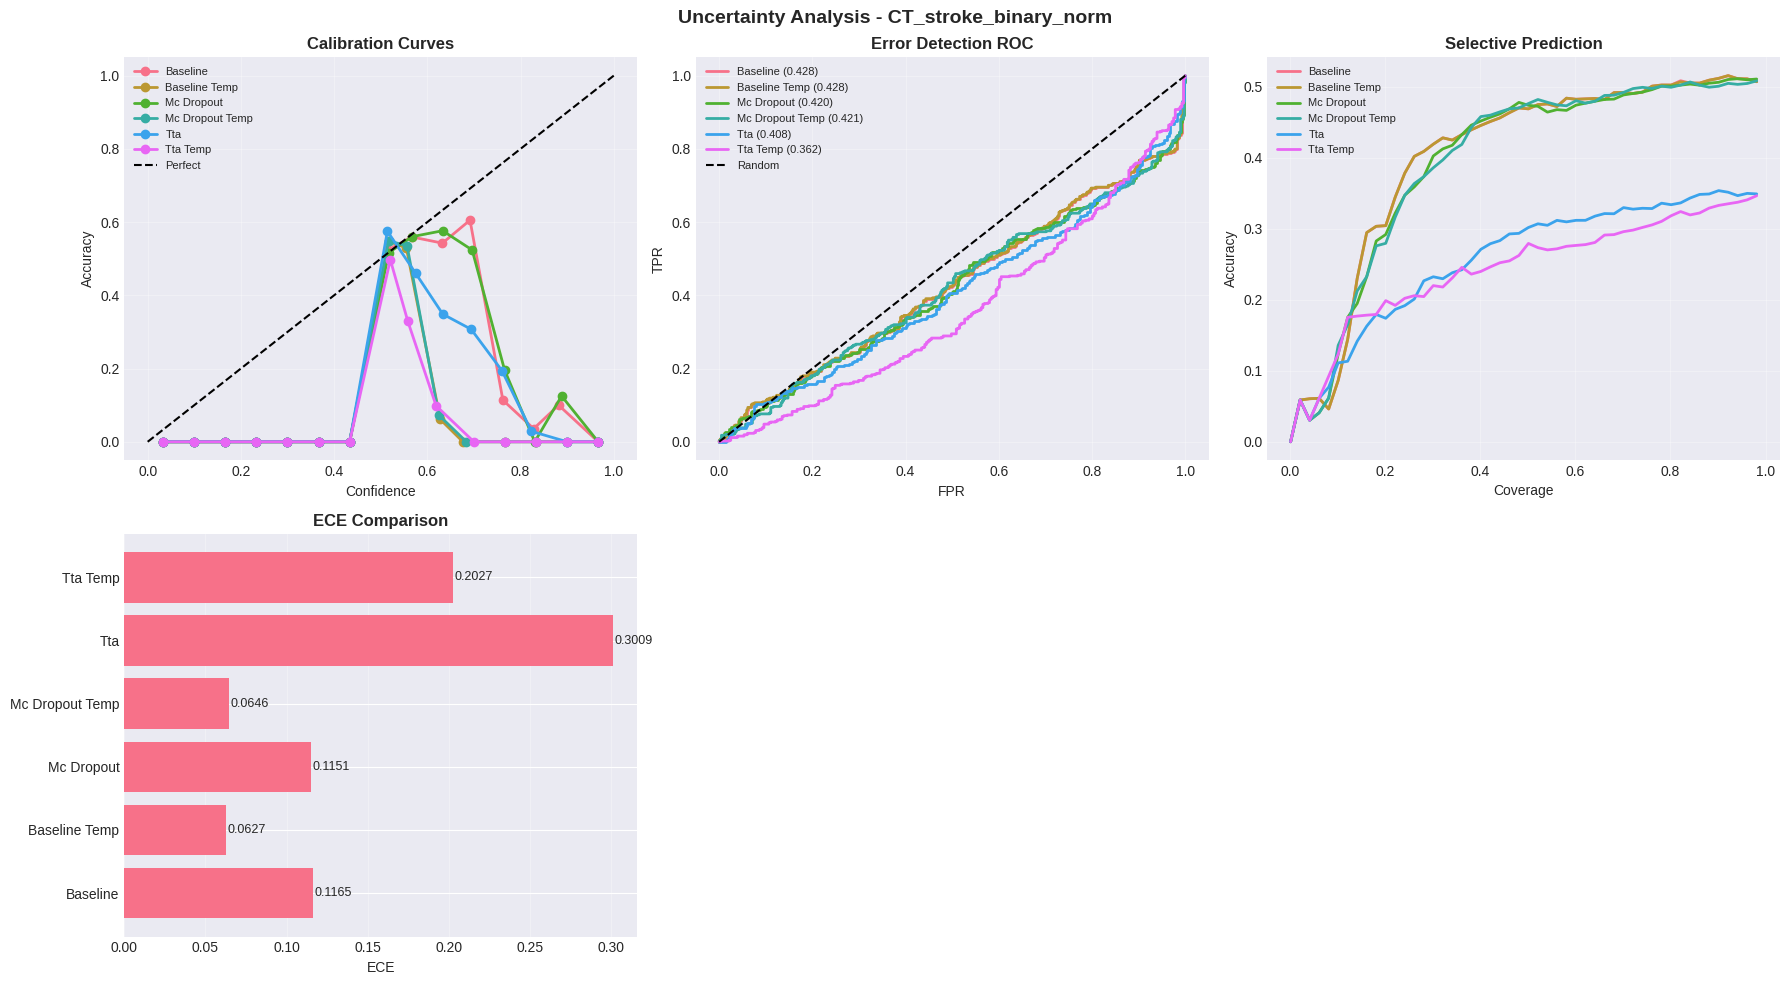


📋 DETAILED METRICS
         method  accuracy      ece  error_auroc  acc@50%  acc@70%  acc@80%  acc@90%               dataset
       baseline   0.50750 0.116495     0.428284 0.470130 0.491743   0.5024 0.509220 CT_stroke_binary_norm
  baseline_temp   0.50750 0.062671     0.428274 0.470130 0.491743   0.5024 0.509220 CT_stroke_binary_norm
     mc_dropout   0.50750 0.115062     0.420407 0.477922 0.482569   0.5008 0.504965 CT_stroke_binary_norm
mc_dropout_temp   0.50750 0.064613     0.420754 0.470130 0.488073   0.5008 0.499291 CT_stroke_binary_norm
            tta   0.35000 0.300939     0.408221 0.293507 0.321101   0.3360 0.348936 CT_stroke_binary_norm
       tta_temp   0.35125 0.202688     0.361505 0.262338 0.291743   0.3104 0.329078 CT_stroke_binary_norm
✅ Saved: ./enhanced_results/metrics_CT_stroke_binary_norm.csv


In [ ]:
datasets = [
    "MRI_ms_norm",
    "CT_stroke_binary_norm"
]
os.makedirs('./enhanced_results', exist_ok=True)
for ds in datasets:
    clear_memory()

    # Run benchmark
    results, metrics_df, labels = run_enhanced_benchmark(
        dataset_name=ds,
        batch_size=2,
        num_workers=0,
        use_temp_scaling=True
    )

    print("\n" + "="*80)
    print("📋 DETAILED METRICS")
    print("="*80)
    print(metrics_df.to_string(index=False))
    metrics_df.to_csv(f'./enhanced_results/metrics_{ds}.csv', index=False)
    print(f"✅ Saved: ./enhanced_results/metrics_{ds}.csv")